<a href="https://colab.research.google.com/github/Likhitha121410/IPL2024_project/blob/main/ipl_2024data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [2]:
df = pd.read_csv("/content/ipl2024 Matches.csv")

df.head()

,id,date,team1,team2,toss_winner,decision,first_score,first_wkts,second_score,second_wkts,winner,player_of_the_match,most_runs,most_wkts
0,1,"March 22,2024",Banglore,Chennai,Banglore,Bat,173,6,176,4,Chennai,Mustafizur Rahman,Anuj Rawat,Mustafizur Rahman
1,2,"March 23,2024",Delhi,Punjab,Punjab,Field,174,9,177,6,Punjab,Sam Curran,Sam Curran,Kuldeep Yadav
2,3,"March 23,2024",Kolkata,Hyderabad,Hyderabad,Field,208,7,204,7,Kolkata,Andre Russell,Andre Russell,T Natarajan
3,4,"March 24,2024",Rajasthan,Lucknow,Rajasthan,Bat,193,4,173,6,Rajasthan,Sanju Samson,Sanju Samson,Trent Boult
4,5,"March 24,2024",Gujarat,Mumbai,Mumbai,Field,168,6,162,9,Gujarat,Sai Sudharsan,Dewald Brevis,Jasprit Bumrah


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   74 non-null     int64 
 1   date                 74 non-null     object
 2   team1                74 non-null     object
 3   team2                74 non-null     object
 4   toss_winner          74 non-null     object
 5   decision             71 non-null     object
 6   first_score          74 non-null     int64 
 7   first_wkts           74 non-null     int64 
 8   second_score         74 non-null     int64 
 9   second_wkts          74 non-null     int64 
 10  winner               74 non-null     object
 11  player_of_the_match  71 non-null     object
 12  most_runs            71 non-null     object
 13  most_wkts            71 non-null     object
dtypes: int64(5), object(9)
memory usage: 8.2+ KB


In [4]:
df.describe()

,id,first_score,first_wkts,second_score,second_wkts
count,74.000000,74.000000,74.000000,74.000000,74.000000
mean,37.500000,180.554054,6.148649,169.054054,5.783784
std,21.505813,51.855474,2.469998,47.651386,2.934305
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,19.250000,162.250000,4.250000,145.250000,3.250000
50%,37.500000,182.500000,6.000000,173.500000,6.000000
75%,55.750000,208.000000,8.000000,198.250000,8.000000
max,74.000000,277.000000,10.000000,262.000000,10.000000


In [5]:
df.shape

(74, 14)

In [6]:
df.columns

Index(['id', 'date', 'team1', 'team2', 'toss_winner', 'decision',
       'first_score', 'first_wkts', 'second_score', 'second_wkts', 'winner',
       'player_of_the_match', 'most_runs', 'most_wkts'],
      dtype='object')

In [7]:
df.isnull().sum()

,0
id,0
date,0
team1,0
team2,0
toss_winner,0
decision,3
first_score,0
first_wkts,0
second_score,0
second_wkts,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

,0
id,int64
date,object
team1,object
team2,object
toss_winner,object
decision,object
first_score,int64
first_wkts,int64
second_score,int64
second_wkts,int64


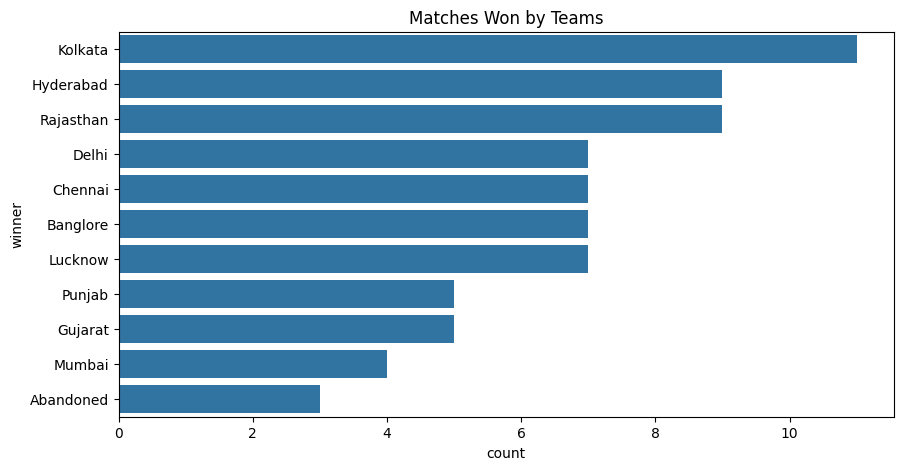

In [10]:
plt.figure(figsize=(10,5))

sns.countplot(y=df['winner'],
              order=df['winner'].value_counts().index)

plt.title("Matches Won by Teams")

plt.show()

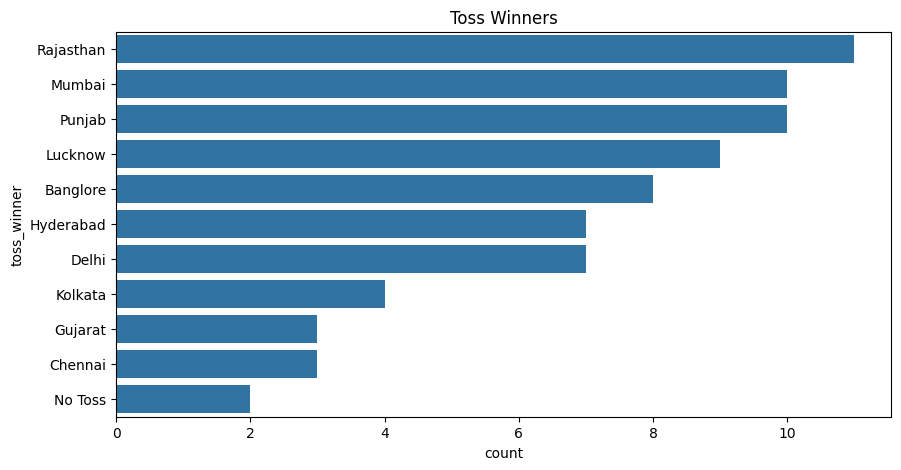

In [12]:
plt.figure(figsize=(10,5))

sns.countplot(y=df['toss_winner'],
              order=df['toss_winner'].value_counts().index)

plt.title("Toss Winners")

plt.show()

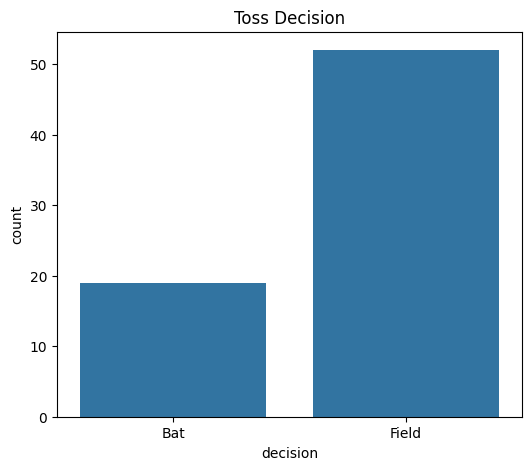

In [13]:
plt.figure(figsize=(6,5))

sns.countplot(x='decision', data=df)

plt.title("Toss Decision")

plt.show()

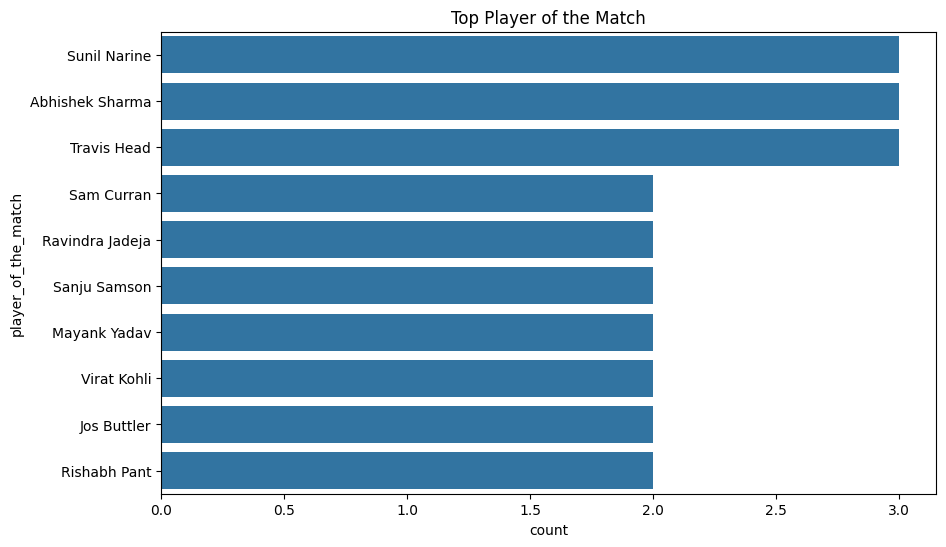

In [14]:
plt.figure(figsize=(10,6))

sns.countplot(y=df['player_of_the_match'],
              order=df['player_of_the_match'].value_counts().head(10).index)

plt.title("Top Player of the Match")

plt.show()

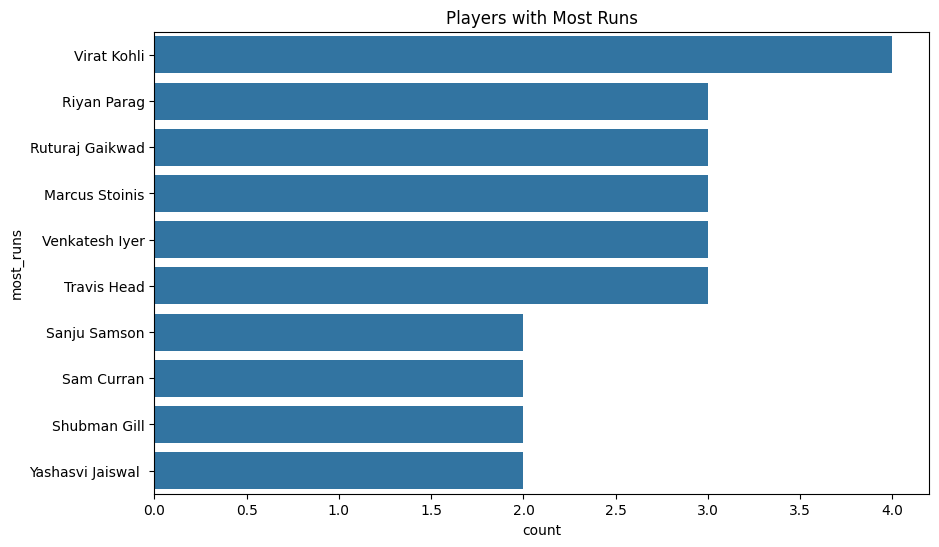

In [15]:
plt.figure(figsize=(10,6))

sns.countplot(y=df['most_runs'],
              order=df['most_runs'].value_counts().head(10).index)

plt.title("Players with Most Runs")

plt.show()

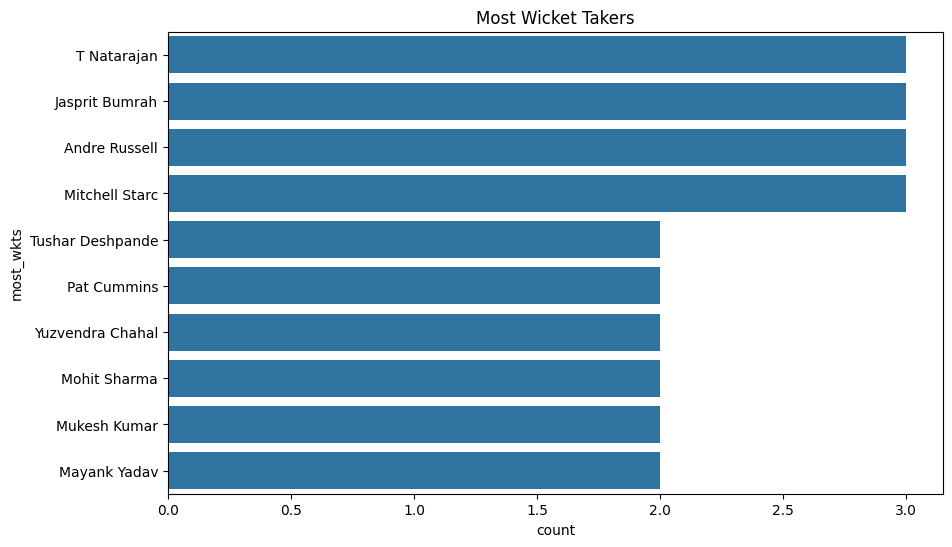

In [16]:
plt.figure(figsize=(10,6))

sns.countplot(y=df['most_wkts'],
              order=df['most_wkts'].value_counts().head(10).index)

plt.title("Most Wicket Takers")

plt.show()

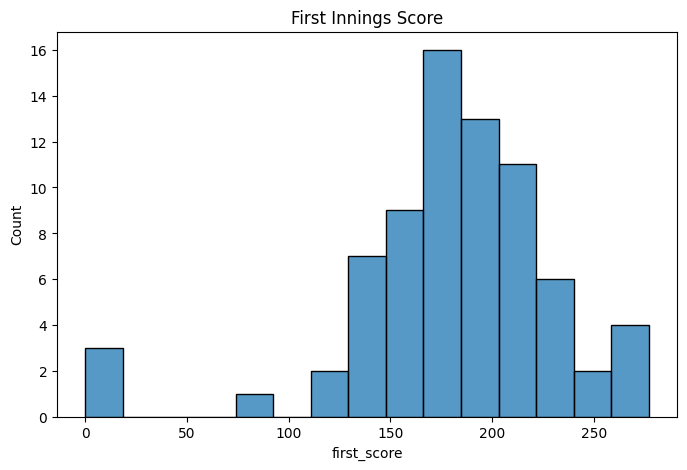

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df['first_score'], bins=15)

plt.title("First Innings Score")

plt.show()

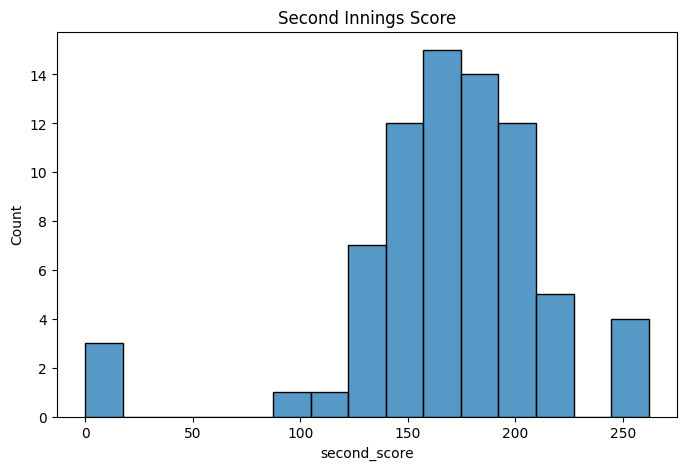

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df['second_score'], bins=15)

plt.title("Second Innings Score")

plt.show()

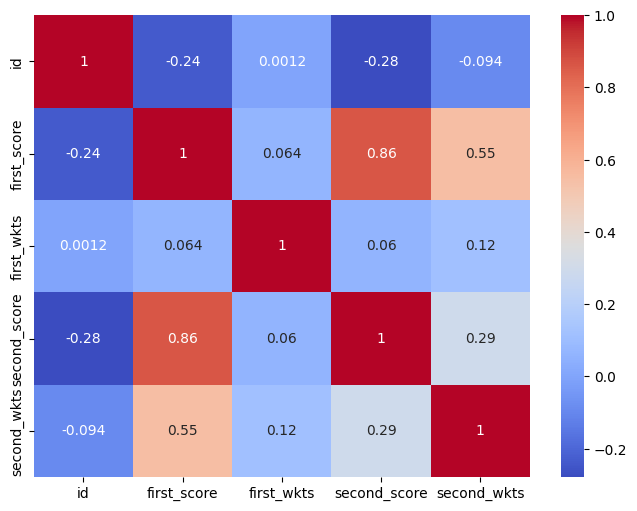

In [19]:
numeric = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(numeric.corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

In [20]:
df.drop(['id','date'], axis=1, inplace=True)

In [21]:
le = LabelEncoder()

for col in df.columns:
    df[col] = le.fit_transform(df[col])

In [22]:
X = df.drop('winner', axis=1)

y = df['winner']

In [23]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

prediction = dt.predict(X_test)

In [25]:
accuracy_score(y_test,prediction)

0.13333333333333333

In [26]:
print(classification_report(y_test,prediction))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         1
           6       0.33      0.50      0.40         2
           7       0.00      0.00      0.00         1
           8       0.00      0.00      0.00         0
           9       0.00      0.00      0.00         0
          10       0.00      0.00      0.00         1

    accuracy                           0.13        15
   macro avg       0.12      0.14      0.13        15
weighted avg       0.11      0.13      0.12        15



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

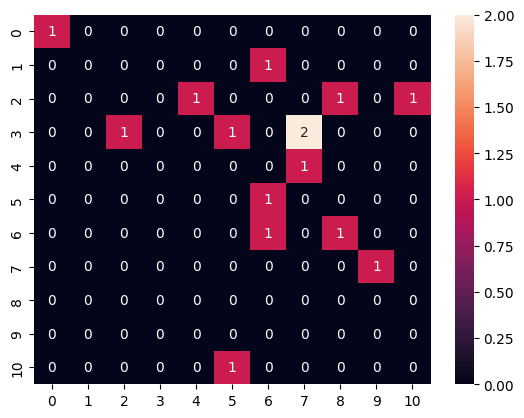

In [27]:
cm = confusion_matrix(y_test,prediction)

sns.heatmap(cm,
            annot=True,
            fmt='d')

plt.show()

In [28]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

pred = rf.predict(X_test)

In [29]:
accuracy_score(y_test,pred)

0.26666666666666666

In [30]:
importance = pd.DataFrame({

'Feature':X.columns,

'Importance':rf.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                Feature  Importance
9             most_runs    0.130432
1                 team2    0.121844
10            most_wkts    0.112824
8   player_of_the_match    0.100266
2           toss_winner    0.099490
5            first_wkts    0.092620
6          second_score    0.092080
0                 team1    0.090075
4           first_score    0.072960
7           second_wkts    0.067428
3              decision    0.019983


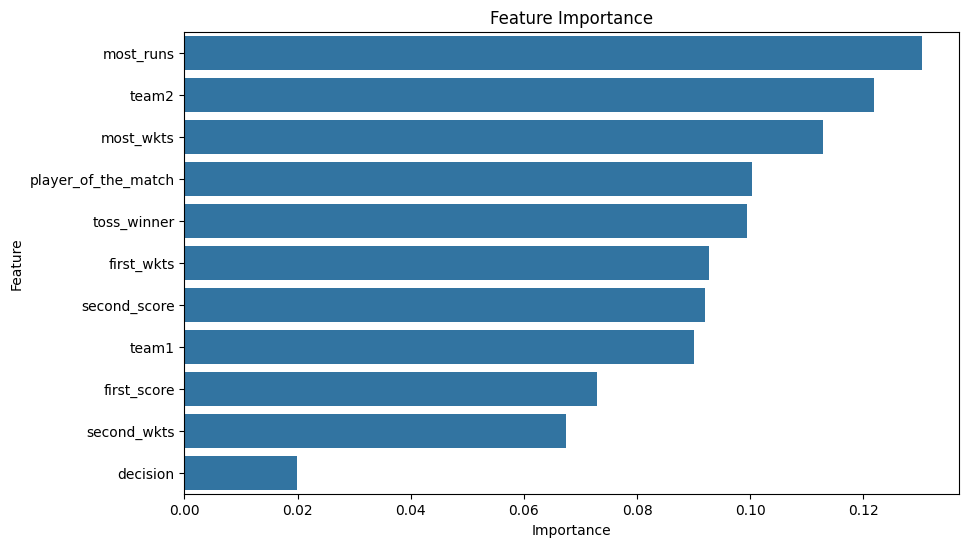

In [31]:
plt.figure(figsize=(10,6))

sns.barplot(data=importance,
            x='Importance',
            y='Feature')

plt.title("Feature Importance")

plt.show()

In [32]:
sample = X.iloc[[0]]

prediction = rf.predict(sample)

print(prediction)

[1]


In [34]:
import os

os.listdir()

['.config', 'ipl2024 Matches.csv', 'sample_data']

In [35]:
!ls

'ipl2024 Matches.csv'   sample_data


In [36]:
df.to_csv("IPL2024_Cleaned_Dataset.csv", index=False)

In [37]:
!ls

 IPL2024_Cleaned_Dataset.csv  'ipl2024 Matches.csv'   sample_data


In [38]:
from google.colab import files

files.download("IPL2024_Cleaned_Dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>